
# Using pre-trained models to solve "standard" NLP problems **without** fine-tuning

Adapted from https://github.com/nlp-with-transformers/notebooks/blob/main/01_introduction.ipynb

We will use the `transformers` library from HuggingFace (in particular, the `pipeline` function) to demonstrate ready-to-use pretrained models for a variety of standard NLP tasks.

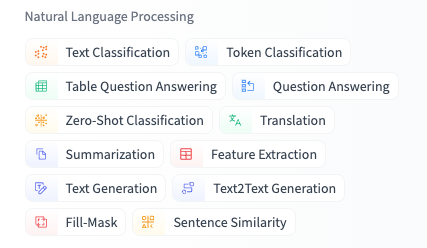

Fortunately, the library is preinstalled in Colab so we can just import it and start using it right away.

We will start with a Text Classification example.

### Text Classification

In [ ]:
text = """Dear Amazon, last week I ordered an Optimus Prime action figure \
from your online store in Germany. Unfortunately, when I opened the package, \
I discovered to my horror that I had been sent an action figure of Megatron \
instead! As a lifelong enemy of the Decepticons, I hope you can understand my \
dilemma. To resolve the issue, I demand an exchange of Megatron for the \
Optimus Prime figure I ordered. Enclosed are copies of my records concerning \
this purchase. I expect to hear from you soon. Sincerely, Bumblebee."""

In [ ]:
from transformers import pipeline

In [ ]:
classifier = pipeline("text-classification")

In [ ]:
outputs = classifier(text)

In [ ]:
outputs

In [ ]:
import pandas as pd
pd.DataFrame(outputs)

,label,score
0,NEGATIVE,0.901546


Let's try another example.


In [ ]:
inputs = ['i hated the movie',
          'if i said i loved the movie, i would be lying',
          'the movie left me speechless',
          ' incredible!',
          'almost but not quite entirely unlike anything good i have ever seen'
          ]

In [ ]:
outputs = classifier(inputs)
pd.DataFrame(outputs)

,label,score
0,NEGATIVE,0.999695
1,NEGATIVE,0.992098
2,NEGATIVE,0.991616
3,POSITIVE,0.999877
4,POSITIVE,0.994624


### Named Entity Recognition

In [ ]:
ner_tagger = pipeline("ner", aggregation_strategy="simple")

In [ ]:
outputs = ner_tagger(text)
pd.DataFrame(outputs)

,entity_group,score,word,start,end
0,ORG,0.879010,Amazon,5,11
1,MISC,0.990859,Optimus Prime,36,49
2,LOC,0.999755,Germany,90,97
3,MISC,0.556569,Mega,208,212
4,PER,0.590257,##tron,212,216
5,ORG,0.669693,Decept,253,259
6,MISC,0.498349,##icons,259,264
7,MISC,0.775361,Megatron,350,358
8,MISC,0.987854,Optimus Prime,367,380
9,PER,0.812096,Bumblebee,502,511


### Question Answering

In [ ]:
reader = pipeline("question-answering")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

In [ ]:
question = "What does the customer want?"
outputs = reader(question=question, context=text)
pd.DataFrame([outputs])

,score,start,end,answer
0,0.631292,335,358,an exchange of Megatron


### Text Generation

In [ ]:
from transformers import set_seed
set_seed(42) # Set the seed to get reproducible results

In [ ]:
generator = pipeline("text-generation")

In [ ]:
response = "Dear Bumblebee, I am sorry to hear that your order was mixed up."
prompt = text + "\n\nCustomer service response:\n" + response

In [ ]:
prompt

'Dear Amazon, last week I ordered an Optimus Prime action figure from your online store in Germany. Unfortunately, when I opened the package, I discovered to my horror that I had been sent an action figure of Megatron instead! As a lifelong enemy of the Decepticons, I hope you can understand my dilemma. To resolve the issue, I demand an exchange of Megatron for the Optimus Prime figure I ordered. Enclosed are copies of my records concerning this purchase. I expect to hear from you soon. Sincerely, Bumblebee.\n\nCustomer service response:\nDear Bumblebee, I am sorry to hear that your order was mixed up.'

In [ ]:
outputs = generator(prompt, max_length=200)
print(outputs[0]['generated_text'])

Yikes!! A bigger model will give us a better response.

You can try the model below later. We will skip it now since it will take a while to download.

In [ ]:
generator = pipeline("text-generation", model='bigscience/bloom')

In [ ]:
outputs = generator(prompt, max_length=200)
print(outputs[0]['generated_text'])